In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import to_rgb, to_hex
from dna_features_viewer import GraphicFeature, GraphicRecord
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import tol_colors as tc

In [53]:
# define constants
COLNAME = "assigned_subcat" # hierarchy level to be analyzed, from here on defined as 'subcategory'
COLNAME_MAP = "Subcategory" # respective column name in the mapping file
TOP_COLNAME = "assigned_top" # hierarchy level to serve as top-level category/mapping
TOP_COLNAME_MAP = "Top_Category" # respective column name in the mapping file
COLORBLIND = True

# assertions
assert COLNAME and TOP_COLNAME in ["assigned_subcat", "assigned_cat", "assigned_top"], "Invalid column name. Must be one of 'assigned_subcat', 'assigned_cat', or 'assigned_top'."
assert COLNAME_MAP and TOP_COLNAME_MAP in ["Subcategory", "Category", "Top_Category"], "Invalid column name. Must be one of 'Subcategory', 'Category', or 'Top_Category'."

In [54]:
#######################
# plotting utilities 
#######################

# define colors for top-level categories
if COLORBLIND:
    topcat_colors = {
    "Assembly": '#6DA1D6',
    "Structural": '#3E79BD',
    "Host takeover": '#F4A937',
    "NA processing": '#C1A7C4',
    "Replication": '#AD7BA4',
    "Translation": '#93C7EC',
    "AMGs": '#B8D29E', #"#ffa200",
    "Lysis": '#2C925B', 
    "Anti-Defense": '#D9070D', 
    "Effectors": '#EB7121',
    "Lysogeny": '#7BB47D', #"#ff007b",
    "Unknown": '#FFFFFF'
}
else:
    topcat_colors = {
        "Assembly": "#007BFF",
        "Structural": "#1e00ff",
        "Host takeover": "#2fff00",
        "NA processing": "#00ffb7",
        "Replication":"#00d9ff",
        "Translation": "#f6ff00",
        "AMGs": "#ffbf00", #"#ffa200",
        "Lysis": "#ff0000", 
        "Anti-Defense": "#ff00dd", 
        "Effectors": "#8e01f9", 
        "Lysogeny": "#FF5A00", #"#ff007b",
        "Unknown": "#bdbdbd"
    }


def adjust_color(color, factor=0.2, lighten=True):
    """Mix a color with white or black. The closer the value to 1, the more white/black contained"""
    r, g, b = to_rgb(color)

    if lighten:
        r = r + (1-r)*factor
        g = g + (1-g)*factor
        b = b + (1-b)*factor
    else:
        r = r * (1-factor)
        g = g * (1-factor)
        b = b * (1-factor)

    return to_hex((r, g, b))


# lighten top-level category colors
if COLORBLIND:
    topcat_colors_adjusted = topcat_colors
else:
    topcat_colors_adjusted = {
    k: adjust_color(v, factor=0.2, lighten=True)
    for k, v in topcat_colors.items()
}

In [55]:
# read mapping file for keywords to sub-, mid-, and top-level categories
keywords_map = pd.read_csv("./input_data/Category_map.csv") 

# create a mapping from subcategories to top-level categories
cat_to_top = keywords_map[[COLNAME_MAP, TOP_COLNAME_MAP]].drop_duplicates().set_index(COLNAME_MAP)[TOP_COLNAME_MAP].to_dict()

In [56]:
################
# Panel E: genomic context
################
basel_95 = pd.read_csv(f"./input_data/BASEL_BacVir95_final.tsv", sep="\t")
if COLORBLIND:
    out_dir_95 = Path("./plots/genomic_context_95_colorblind")
else:
    out_dir_95 = Path("./plots/genomic_context_95")
out_dir_95.mkdir(parents=True, exist_ok=True)

basel_20 = pd.read_csv(f"./input_data/BASEL_BacVir20_final.tsv", sep="\t")
if COLORBLIND:
    out_dir_20 = Path("./plots/genomic_context_20_colorblind")
else:
    out_dir_20 = Path("./plots/genomic_context_20")
out_dir_20.mkdir(parents=True, exist_ok=True)

In [57]:
def find_candidate_regions(df, df_20=None, min_proteins=8, min_unknown_pred=4, unknown_threshold=0.4, mean_threshold=0.8,
    mean_threshold_20=0.7, max_proteins=30, max_known_deviations=2):
    candidates = []

    for organism, group in df.groupby("organism"):
        group = group.sort_values("start").reset_index(drop=True)

        unknown_idx = group.index[group["assigned_subcat_initial"] == "Unknown"].tolist()

        if len(unknown_idx) < min_unknown_pred:
            continue

        for i in range(len(unknown_idx)):
            first_idx = unknown_idx[i]

            for j in range(i + min_unknown_pred - 1, len(unknown_idx)):
                last_idx = unknown_idx[j]
                region = group.iloc[first_idx:last_idx + 1].copy()

                # Extend region to the left
                left_idx = first_idx - 1

                while left_idx >= 0:
                    candidate = group.iloc[left_idx]
                    first_unknown = group.iloc[first_idx]
                    same_assigned = (candidate["assigned_subcat_initial"] == first_unknown["assigned_subcat_initial"])
                    same_predicted = (candidate["Predicted Class"] == first_unknown["Predicted Class"])

                    if same_assigned or same_predicted:
                        first_idx = left_idx
                        left_idx -= 1
                    else:
                        break

                # Extend region to the right
                right_idx = last_idx + 1

                while right_idx < len(group):
                    candidate = group.iloc[right_idx]
                    last_unknown = group.iloc[last_idx]
                    same_assigned = (candidate["assigned_subcat_initial"] == last_unknown["assigned_subcat_initial"])
                    same_predicted = (candidate["Predicted Class"] == last_unknown["Predicted Class"])

                    if same_assigned or same_predicted:
                        last_idx = right_idx
                        right_idx += 1
                    else:
                        break

                # Recreate the extended region
                region = group.iloc[first_idx:last_idx + 1].copy()

                if len(region) > max_proteins:
                    break

                # Unknown proteins with P(Predicted) > threshold
                unknown_pred = ((region["assigned_subcat_initial"] == "Unknown") & (region["P(Predicted)"] > unknown_threshold))
                n_unknown_pred = unknown_pred.sum()
                mean_pred = region["P(Predicted)"].mean()

                if (len(region) < min_proteins or n_unknown_pred < min_unknown_pred or mean_pred <= mean_threshold):
                    continue

                # Initially characterized proteins: allow at most 2 prediction deviations
                known = region[region["assigned_subcat_initial"] != "Unknown"]
                known_deviations = (known["assigned_subcat_initial"] != known["Predicted Class"]).sum()

                if known_deviations > max_known_deviations:
                    continue

                # Check BASEL20
                protein_ids = region["protein_ID"].tolist()

                if df_20 is not None:
                    region_20 = df_20[df_20["protein_ID"].isin(protein_ids)].copy()

                    # Require all proteins to be present in BASEL20
                    if len(region_20) != len(region):
                        continue

                    mean_pred_20 = region_20["P(Predicted)"].mean()

                    if mean_pred_20 < mean_threshold_20:
                        continue

                    # BASEL95 vs BASEL20 predicted classes must be identical
                    comparison = region[["protein_ID", "Predicted Class"]].merge(region_20[["protein_ID", "Predicted Class"]],
                    on="protein_ID", suffixes=("_95", "_20"))

                    # Require all proteins to be comparable
                    if len(comparison) != len(region):
                        continue

                    prediction_deviations = (comparison["Predicted Class_95"] != comparison["Predicted Class_20"]).sum()

                    # No deviations allowed
                    if prediction_deviations > 0:
                        continue

                else:
                    mean_pred_20 = None
                    prediction_deviations = None

                # Store candidate
                candidates.append({
                    "organism": organism,
                    "n_proteins": len(region),
                    "n_unknown_pred": n_unknown_pred,
                    "n_known_deviations": known_deviations,
                    "n_prediction_deviations_95_20": prediction_deviations,
                    "mean_P_predicted": mean_pred,
                    "mean_P_predicted_20": mean_pred_20,
                    "start": region["start"].min(),
                    "end": region["end"].max(),
                    "span": region["end"].max() - region["start"].min(),
                    "protein_IDs": protein_ids,
                    "category_sequence": tuple(region["Predicted Class"]),
                })

    candidates = pd.DataFrame(candidates)

    if len(candidates):
        candidates = candidates.sort_values(
            ["mean_P_predicted", "n_unknown_pred", "n_proteins"],
            ascending=[False, False, False],
        ).drop_duplicates("category_sequence").reset_index(drop=True)

    return candidates

In [58]:
candidates = find_candidate_regions(basel_95, df_20=basel_20)

In [59]:
col_map = topcat_colors_adjusted
cmap = tc.PRGn #cm.get_cmap('viridis') 
norm = mcolors.Normalize(vmin=0, vmax=1) # normalize to 0-1

def plot_region(df, phage, start, end, i, out_dir):
    phage_selected = df[df["organism"] == phage].copy()

    phage_selected["plot_cat_assigned"] = phage_selected["assigned_subcat_initial"].map(cat_to_top)
    phage_selected["plot_cat_pred"] = phage_selected["Predicted Class"].map(cat_to_top)

    features_assigned = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_assigned"]]) for _, row in phage_selected.iterrows()]
    features_pred = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_pred"]]) for _, row in phage_selected.iterrows()]
    features_prob = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=cmap(norm(row["P(Predicted)"]))) for _, row in phage_selected.iterrows()]

    record_assigned = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_assigned)
    record_pred = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_pred)
    record_prob = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_prob)

    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 4), sharex=True)

    record_assigned.plot(ax=ax1, figure_width=15, figure_height=9)
    record_pred.plot(ax=ax2, figure_width=15, figure_height=9)
    record_prob.plot(ax=ax3, figure_width=15, figure_height=9)

    ax1.set_xlim(start, end)
    ax2.set_xlim(start, end)

    ax1.text(0.35, 0.7, "True labels", transform=ax1.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
    ax2.text(0.51, 0.7, "Predicted labels", transform=ax2.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
    ax3.text(0.39, 0.7, "Probabilities", transform=ax3.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")

    fig.savefig(out_dir / f"{i}_{phage}_{start}_{end}.png", dpi=300, bbox_inches="tight")
    plt.close(fig)


In [60]:
for i, cand in candidates.iterrows():
    if i > 50:
        break
    plot_region(basel_95, cand["organism"], cand["start"], cand["end"], i, out_dir_95)
    plot_region(basel_20, cand["organism"], cand["start"], cand["end"], i, out_dir_20)

273


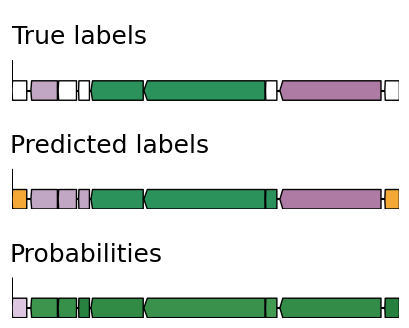

In [61]:
### manual inspection results

phage_selected = basel_95[basel_95["organism"] == "Escherichia phage AugustSocin"].copy()
print(len(phage_selected))

phage_selected["plot_cat_assigned"] = phage_selected["assigned_subcat_initial"].map(cat_to_top)
phage_selected["plot_cat_pred"] = phage_selected["Predicted Class"].map(cat_to_top)

features_assigned = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_assigned"]]) for _, row in phage_selected.iterrows()]
features_pred = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_pred"]]) for _, row in phage_selected.iterrows()]
features_prob = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=cmap(norm(row["P(Predicted)"]))) for _, row in phage_selected.iterrows()]

record_assigned = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_assigned)
record_pred = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_pred)
record_prob = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_prob)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 4), sharex=True)

record_assigned.plot(ax=ax1, figure_width=15, figure_height=9)
record_pred.plot(ax=ax2, figure_width=15, figure_height=9)
record_prob.plot(ax=ax3, figure_width=15, figure_height=9)

ax1.set_xlim(72050, 79017)
ax2.set_xlim(72050, 79017)
#72882	79017

ax1.text(0.35, 0.7, "True labels", transform=ax1.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax2.text(0.51, 0.7, "Predicted labels", transform=ax2.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax3.text(0.39, 0.7, "Probabilities", transform=ax3.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")

plt.show() 

fig.savefig(out_dir_95 / "1.png", dpi=300, bbox_inches="tight")
plt.close(fig)

229


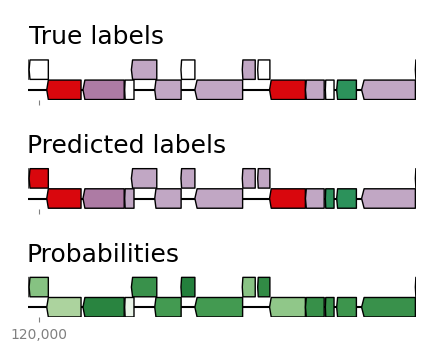

In [62]:
phage_selected = basel_95[basel_95["organism"] == "Escherichia phage CarlMeissner"].copy()
print(len(phage_selected))

phage_selected["plot_cat_assigned"] = phage_selected["assigned_subcat_initial"].map(cat_to_top)
phage_selected["plot_cat_pred"] = phage_selected["Predicted Class"].map(cat_to_top)

features_assigned = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_assigned"]]) for _, row in phage_selected.iterrows()]
features_pred = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_pred"]]) for _, row in phage_selected.iterrows()]
features_prob = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=cmap(norm(row["P(Predicted)"]))) for _, row in phage_selected.iterrows()]

record_assigned = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_assigned)
record_pred = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_pred)
record_prob = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_prob)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 4), sharex=True)

record_assigned.plot(ax=ax1, figure_width=15, figure_height=9)
record_pred.plot(ax=ax2, figure_width=15, figure_height=9)
record_prob.plot(ax=ax3, figure_width=15, figure_height=9)

ax1.set_xlim(119_750, 129_000)
ax2.set_xlim(119_750, 129_000)

ax1.text(0.35, 0.7, "True labels", transform=ax1.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax2.text(0.51, 0.7, "Predicted labels", transform=ax2.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax3.text(0.39, 0.7, "Probabilities", transform=ax3.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")

plt.show() 

fig.savefig(out_dir_95 / "2.png", dpi=300, bbox_inches="tight")
plt.close(fig)

229


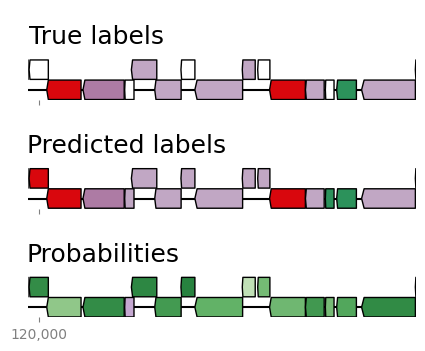

In [63]:
phage_selected = basel_20[basel_20["organism"] == "Escherichia phage CarlMeissner"].copy()
print(len(phage_selected))

phage_selected["plot_cat_assigned"] = phage_selected["assigned_subcat_initial"].map(cat_to_top)
phage_selected["plot_cat_pred"] = phage_selected["Predicted Class"].map(cat_to_top)

features_assigned = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_assigned"]]) for _, row in phage_selected.iterrows()]
features_pred = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_pred"]]) for _, row in phage_selected.iterrows()]
features_prob = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=cmap(norm(row["P(Predicted)"]))) for _, row in phage_selected.iterrows()]

record_assigned = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_assigned)
record_pred = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_pred)
record_prob = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_prob)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(5, 4), sharex=True)

record_assigned.plot(ax=ax1, figure_width=15, figure_height=9)
record_pred.plot(ax=ax2, figure_width=15, figure_height=9)
record_prob.plot(ax=ax3, figure_width=15, figure_height=9)

ax1.set_xlim(119_750, 129_000)
ax2.set_xlim(119_750, 129_000)

ax1.text(0.35, 0.7, "True labels", transform=ax1.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax2.text(0.51, 0.7, "Predicted labels", transform=ax2.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax3.text(0.39, 0.7, "Probabilities", transform=ax3.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")

plt.show() 

fig.savefig(out_dir_20 / "2.png", dpi=300, bbox_inches="tight")
plt.close(fig)

277


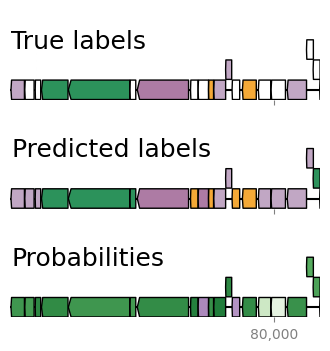

In [64]:
phage_selected = basel_95[basel_95["organism"] == "Escherichia phage AndreasVesalius"].copy()
print(len(phage_selected))

phage_selected["plot_cat_assigned"] = phage_selected["assigned_subcat_initial"].map(cat_to_top)
phage_selected["plot_cat_pred"] = phage_selected["Predicted Class"].map(cat_to_top)

features_assigned = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_assigned"]]) for _, row in phage_selected.iterrows()]
features_pred = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_pred"]]) for _, row in phage_selected.iterrows()]
features_prob = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=cmap(norm(row["P(Predicted)"]))) for _, row in phage_selected.iterrows()]

record_assigned = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_assigned)
record_pred = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_pred)
record_prob = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_prob)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(4, 4), sharex=True)

record_assigned.plot(ax=ax1, figure_width=15, figure_height=9)
record_pred.plot(ax=ax2, figure_width=15, figure_height=9)
record_prob.plot(ax=ax3, figure_width=15, figure_height=9)

ax1.set_xlim(70_650, 81_640)
ax2.set_xlim(70_650, 81_640)

ax1.text(0.44, 0.65, "True labels", transform=ax1.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax2.text(0.65, 0.65, "Predicted labels", transform=ax2.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax3.text(0.5, 0.65, "Probabilities", transform=ax3.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")

plt.show() 

fig.savefig(out_dir_95 / "3.png", dpi=300, bbox_inches="tight")
plt.close(fig)

82


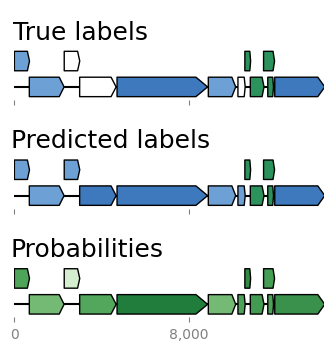

In [65]:
phage_selected = basel_95[basel_95["organism"] == "Escherichia phage AlfredRasser"].copy()
print(len(phage_selected))

phage_selected["plot_cat_assigned"] = phage_selected["assigned_subcat_initial"].map(cat_to_top)
phage_selected["plot_cat_pred"] = phage_selected["Predicted Class"].map(cat_to_top)

features_assigned = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_assigned"]]) for _, row in phage_selected.iterrows()]
features_pred = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_pred"]]) for _, row in phage_selected.iterrows()]
features_prob = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=cmap(norm(row["P(Predicted)"]))) for _, row in phage_selected.iterrows()]

record_assigned = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_assigned)
record_pred = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_pred)
record_prob = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_prob)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(4, 4), sharex=True)

record_assigned.plot(ax=ax1, figure_width=15, figure_height=9)
record_pred.plot(ax=ax2, figure_width=15, figure_height=9)
record_prob.plot(ax=ax3, figure_width=15, figure_height=9)

ax1.set_xlim(0, 14_200)
ax2.set_xlim(0, 14_200)

ax1.text(0.43, 0.75, "True labels", transform=ax1.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax2.text(0.63, 0.75, "Predicted labels", transform=ax2.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax3.text(0.48, 0.75, "Probabilities", transform=ax3.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")

plt.show() 

fig.savefig(out_dir_95 / "4.png", dpi=300, bbox_inches="tight")
plt.close(fig)

221


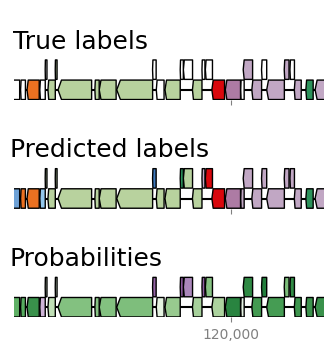

In [66]:
phage_selected = basel_95[basel_95["organism"] == "Escherichia phage AlexBoehm"].copy()
print(len(phage_selected))

phage_selected["plot_cat_assigned"] = phage_selected["assigned_subcat_initial"].map(cat_to_top)
phage_selected["plot_cat_pred"] = phage_selected["Predicted Class"].map(cat_to_top)

features_assigned = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_assigned"]]) for _, row in phage_selected.iterrows()]
features_pred = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_pred"]]) for _, row in phage_selected.iterrows()]
features_prob = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=cmap(norm(row["P(Predicted)"]))) for _, row in phage_selected.iterrows()]

record_assigned = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_assigned)
record_pred = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_pred)
record_prob = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_prob)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(4, 4), sharex=True)

record_assigned.plot(ax=ax1, figure_width=15, figure_height=9)
record_pred.plot(ax=ax2, figure_width=15, figure_height=9)
record_prob.plot(ax=ax3, figure_width=15, figure_height=9)

ax1.set_xlim(106_000, 126_000)
ax2.set_xlim(106_000, 126_000)

ax1.text(0.43, 0.65, "True labels", transform=ax1.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax2.text(0.63, 0.65, "Predicted labels", transform=ax2.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax3.text(0.48, 0.65, "Probabilities", transform=ax3.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")

plt.show() 

fig.savefig(out_dir_95 / "5.png", dpi=300, bbox_inches="tight")
plt.close(fig)

271


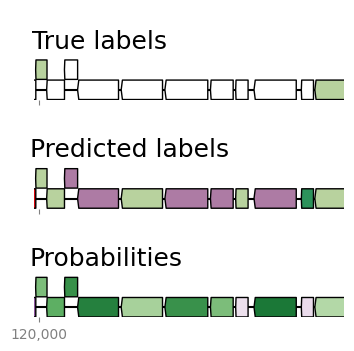

In [67]:
phage_selected = basel_95[basel_95["organism"] == "Escherichia phage AlbertHofmann"].copy()
print(len(phage_selected))

phage_selected["plot_cat_assigned"] = phage_selected["assigned_subcat_initial"].map(cat_to_top)
phage_selected["plot_cat_pred"] = phage_selected["Predicted Class"].map(cat_to_top)

features_assigned = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_assigned"]]) for _, row in phage_selected.iterrows()]
features_pred = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_pred"]]) for _, row in phage_selected.iterrows()]
features_prob = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=cmap(norm(row["P(Predicted)"]))) for _, row in phage_selected.iterrows()]

record_assigned = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_assigned)
record_pred = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_pred)
record_prob = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_prob)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(4, 4), sharex=True)

record_assigned.plot(ax=ax1, figure_width=15, figure_height=9)
record_pred.plot(ax=ax2, figure_width=15, figure_height=9)
record_prob.plot(ax=ax3, figure_width=15, figure_height=9)

ax1.set_xlim(119_900, 127_100)
ax2.set_xlim(119_900, 127_100)

ax1.text(0.43, 0.65, "True labels", transform=ax1.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax2.text(0.63, 0.65, "Predicted labels", transform=ax2.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax3.text(0.48, 0.65, "Probabilities", transform=ax3.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")

plt.show() 

fig.savefig(out_dir_95 / "6.png", dpi=300, bbox_inches="tight")
plt.close(fig)

271


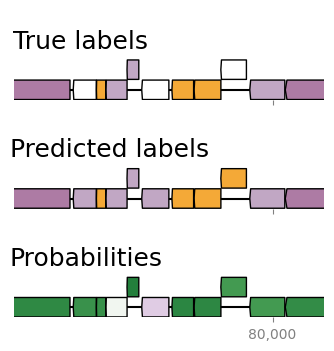

In [68]:
phage_selected = basel_95[basel_95["organism"] == "Escherichia phage AlbertHofmann"].copy()
print(len(phage_selected))

phage_selected["plot_cat_assigned"] = phage_selected["assigned_subcat_initial"].map(cat_to_top)
phage_selected["plot_cat_pred"] = phage_selected["Predicted Class"].map(cat_to_top)

features_assigned = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_assigned"]]) for _, row in phage_selected.iterrows()]
features_pred = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=col_map[row["plot_cat_pred"]]) for _, row in phage_selected.iterrows()]
features_prob = [GraphicFeature(start=row["start"], end=row["end"], strand=row["strand"], color=cmap(norm(row["P(Predicted)"]))) for _, row in phage_selected.iterrows()]

record_assigned = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_assigned)
record_pred = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_pred)
record_prob = GraphicRecord(sequence_length=phage_selected["end"].max(), features=features_prob)

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(4, 4), sharex=True)

record_assigned.plot(ax=ax1, figure_width=15, figure_height=9)
record_pred.plot(ax=ax2, figure_width=15, figure_height=9)
record_prob.plot(ax=ax3, figure_width=15, figure_height=9)

ax1.set_xlim(75_000, 81_000)
ax2.set_xlim(75_000, 81_000)

ax1.text(0.43, 0.65, "True labels", transform=ax1.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax2.text(0.63, 0.65, "Predicted labels", transform=ax2.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")
ax3.text(0.48, 0.65, "Probabilities", transform=ax3.transAxes, ha="right", va="center", fontsize=18, fontweight="medium")

plt.show() 

fig.savefig(out_dir_95 / "7.png", dpi=300, bbox_inches="tight")
plt.close(fig)